# v03 Synthetic Data - Exploration & Consistency Check

Notebook này dùng để:
- Khám phá dữ liệu `raw` (`accounts`, `transactions`, `merchants`)
- Kiểm tra chất lượng dữ liệu cơ bản (missing, kiểu dữ liệu, phân phối)
- Đối soát `ground_truth/fraud_rings.json` với giao dịch fraud

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 200)

cwd = Path.cwd().resolve()
if cwd.name.lower() == "notebooks":
    project_root = cwd.parent
elif (cwd / "notebooks").exists():
    project_root = cwd
else:
    raise RuntimeError("Cannot locate project root. Please run from project root or notebooks folder.")

data_root = project_root / "data" / "synthetic" / "v03"
raw_dir = data_root / "raw"
ground_truth_path = data_root / "ground_truth" / "fraud_rings.json"

print(f"Project root: {project_root}")
print(f"Data root   : {data_root}")

for p in [raw_dir / "accounts.csv", raw_dir / "transactions.csv", raw_dir / "merchants.csv", ground_truth_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")
print("All required files found.")

Project root: D:\FraudRing
Data root   : D:\FraudRing\data\synthetic\v03
All required files found.


In [2]:
accounts = pd.read_csv(raw_dir / "accounts.csv")
transactions = pd.read_csv(raw_dir / "transactions.csv")
merchants = pd.read_csv(raw_dir / "merchants.csv")

if "timestamp_dt" in transactions.columns:
    transactions["timestamp_dt"] = pd.to_datetime(transactions["timestamp_dt"], errors="coerce")

with open(ground_truth_path, "r", encoding="utf-8") as f:
    fraud_rings_gt = json.load(f)

print("accounts     :", accounts.shape)
print("transactions :", transactions.shape)
print("merchants    :", merchants.shape)
print("total_rings  :", fraud_rings_gt.get("total_rings"))

accounts     : (5225, 14)
transactions : (50572, 15)
merchants    : (200, 7)
total_rings  : 45


In [3]:
accounts.head()

,account_id,customer_id,customer_name,account_type,created_date,account_age_days,kyc_risk_score,kyc_level,daily_limit_usd,avg_transaction_amount,monthly_transaction_count,is_blacklisted,status,fraud_ring_member
0,ACC_000001,CUST_000001,Customer 1,savings,2022-08-02,1156,0.103,verified,25000,1639.52,44,False,active,False
1,ACC_000002,CUST_000002,Customer 2,checking,2024-09-23,373,0.351,verified,100000,1237.42,42,False,active,False
2,ACC_000003,CUST_000003,Customer 3,checking,2021-05-01,1614,0.009,verified,50000,2232.82,34,False,active,False
3,ACC_000004,CUST_000004,Customer 4,business,2022-07-05,1184,0.181,verified,10000,2456.39,36,False,active,False
4,ACC_000005,CUST_000005,Customer 5,savings,2023-01-20,985,0.245,verified,100000,1783.06,39,False,active,False


In [4]:
transactions.head()

,transaction_id,source_account,destination_account,amount_usd,original_amount,original_currency,timestamp,date,hour,channel,transaction_type,is_fraud,fraud_ring_id,cycle_num,timestamp_dt
0,TXN_000009101,ACC_000667,ACC_002631,0.04,1022.07,VND,2025-12-04 08:11:00,2025-12-04,8,mobile,p2p,0,NaN,NaN,2025-12-04 08:11:00
1,TXN_000039154,ACC_004043,ACC_003069,0.08,1981.63,VND,2025-12-16 09:01:00,2025-12-16,9,online,p2p,0,NaN,NaN,2025-12-16 09:01:00
2,TXN_000021891,ACC_000942,ACC_002795,0.07,1673.51,VND,2025-10-12 23:20:00,2025-10-12,23,mobile,p2p,0,NaN,NaN,2025-10-12 23:20:00
3,TXN_000019713,ACC_001560,ACC_003879,0.06,1454.92,VND,2025-11-15 15:47:00,2025-11-15,15,atm,p2p,0,NaN,NaN,2025-11-15 15:47:00
4,TXN_000045256,ACC_001671,ACC_003051,0.05,1220.39,VND,2025-10-19 11:35:00,2025-10-19,11,online,p2p,0,NaN,NaN,2025-10-19 11:35:00


In [5]:
merchants.head()

,merchant_id,merchant_name,merchant_type,category,risk_level,is_verified,country
0,MER_000001,Merchant 1,bank,telecom,high,True,Vietnam
1,MER_000002,Merchant 2,retail,retail,high,True,Vietnam
2,MER_000003,Merchant 3,bank,services,high,True,Vietnam
3,MER_000004,Merchant 4,retail,utilities,high,True,Vietnam
4,MER_000005,Merchant 5,retail,utilities,high,True,Vietnam


In [6]:
def missing_summary(df, name):
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "dtype": df.dtypes.astype(str).values,
    }).sort_values(["missing_count", "column"], ascending=[False, True])
    print(f"\n=== Missing summary: {name} ===")
    return out

missing_summary(accounts, "accounts").head(20)


=== Missing summary: accounts ===


,column,missing_count,missing_pct,dtype
5,account_age_days,0,0.0,int64
0,account_id,0,0.0,object
3,account_type,0,0.0,object
9,avg_transaction_amount,0,0.0,float64
4,created_date,0,0.0,object
1,customer_id,0,0.0,object
2,customer_name,0,0.0,object
8,daily_limit_usd,0,0.0,int64
13,fraud_ring_member,0,0.0,bool
11,is_blacklisted,0,0.0,bool


In [7]:
missing_summary(transactions, "transactions").head(20)


=== Missing summary: transactions ===


,column,missing_count,missing_pct,dtype
13,cycle_num,47500,93.93,float64
12,fraud_ring_id,47500,93.93,object
3,amount_usd,0,0.00,float64
9,channel,0,0.00,object
7,date,0,0.00,object
2,destination_account,0,0.00,object
8,hour,0,0.00,int64
11,is_fraud,0,0.00,int64
4,original_amount,0,0.00,float64
5,original_currency,0,0.00,object


In [8]:
missing_summary(merchants, "merchants").head(20)


=== Missing summary: merchants ===


,column,missing_count,missing_pct,dtype
3,category,0,0.0,object
6,country,0,0.0,object
5,is_verified,0,0.0,bool
0,merchant_id,0,0.0,object
1,merchant_name,0,0.0,object
2,merchant_type,0,0.0,object
4,risk_level,0,0.0,object


In [9]:
print("=== Key stats ===")
display(transactions[["amount_usd", "original_amount"]].describe().T)
display(accounts[["account_age_days", "kyc_risk_score", "daily_limit_usd", "avg_transaction_amount", "monthly_transaction_count"]].describe().T)

=== Key stats ===


,count,mean,std,min,25%,50%,75%,max
amount_usd,50572.0,12276.210448,58793.698572,0.02,0.0500,0.080,1327.745,729056.34
original_amount,50572.0,13303.751012,58585.045828,337.75,1216.1425,1539.675,1979.850,729056.34


,count,mean,std,min,25%,50%,75%,max
account_age_days,5225.0,986.506603,580.510672,10.000,473.00,986.000,1478.000,1999.000
kyc_risk_score,5225.0,0.217029,0.147889,0.003,0.11,0.186,0.288,0.926
daily_limit_usd,5225.0,47290.909091,34173.482669,10000.000,25000.00,50000.000,100000.000,100000.000
avg_transaction_amount,5225.0,1783.147989,1545.392806,100.000,1184.50,1531.030,1892.110,16018.020
monthly_transaction_count,5225.0,39.221244,7.602493,7.000,35.00,40.000,44.000,66.000


In [10]:
print("Fraud label distribution:")
fraud_dist = transactions["is_fraud"].value_counts(dropna=False).rename_axis("is_fraud").reset_index(name="count")
fraud_dist["pct"] = (fraud_dist["count"] / len(transactions) * 100).round(2)
display(fraud_dist)

print("Fraud rate by channel:")
channel_stats = transactions.groupby("channel", dropna=False)["is_fraud"].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})
channel_stats["fraud_rate"] = (channel_stats["fraud_rate"] * 100).round(2)
display(channel_stats.sort_values("fraud_rate", ascending=False))

Fraud label distribution:


,is_fraud,count,pct
0,0,47500,93.93
1,1,3072,6.07


Fraud rate by channel:


,count,fraud_rate
channel,,
peer_to_peer,3072,100.0
atm,4928,0.0
branch,2378,0.0
mobile,16673,0.0
online,23521,0.0


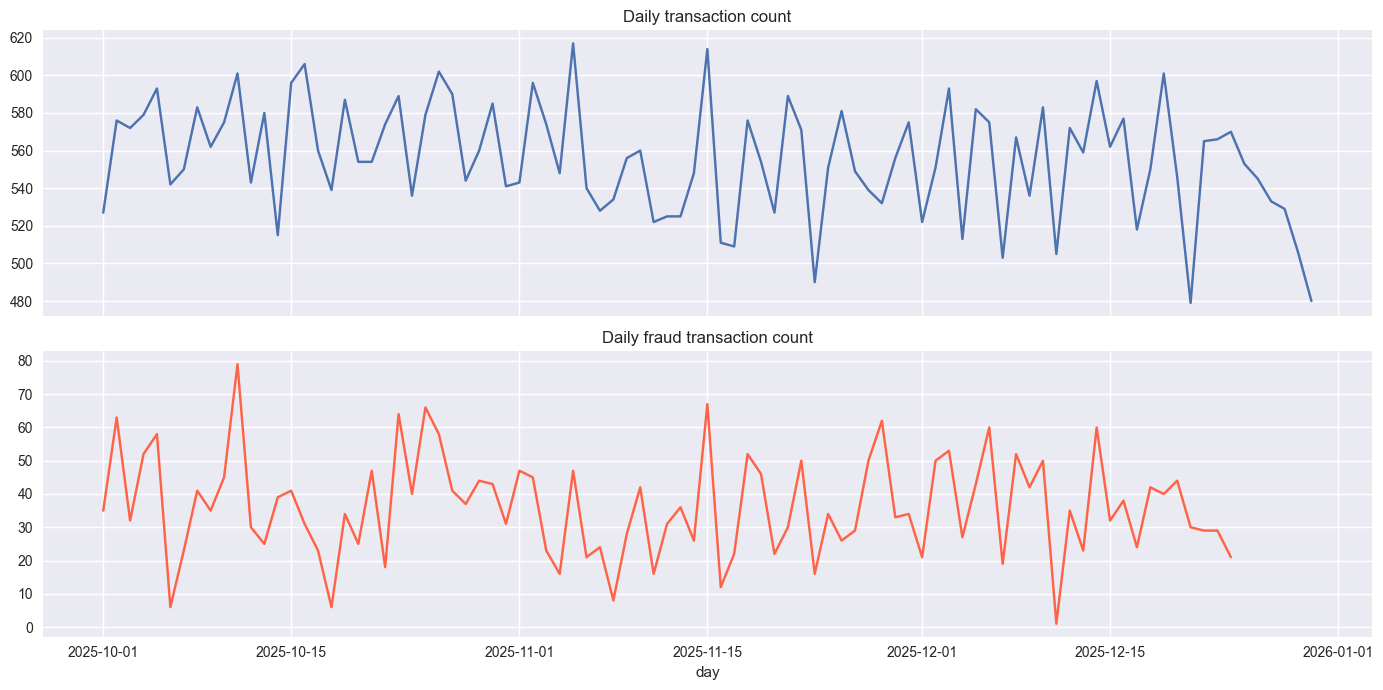

In [11]:
if "timestamp_dt" in transactions.columns and transactions["timestamp_dt"].notna().any():
    daily = transactions.assign(day=transactions["timestamp_dt"].dt.date).groupby("day")["transaction_id"].count()
    daily_fraud = transactions[transactions["is_fraud"] == 1].assign(day=transactions["timestamp_dt"].dt.date).groupby("day")["transaction_id"].count()

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    daily.plot(ax=axes[0], title="Daily transaction count")
    daily_fraud.plot(ax=axes[1], title="Daily fraud transaction count", color="tomato")
    plt.tight_layout()
    plt.show()
else:
    print("No valid timestamp_dt for time-series plot.")

In [12]:
rings = fraud_rings_gt.get("rings", [])
def _tx_count_from_gt(value):
    if isinstance(value, list):
        return len(value)
    if pd.isna(value):
        return None
    return int(value)

rings_df = pd.DataFrame([
    {
        "ring_id": str(r.get("ring_id")),
        "ring_type": r.get("ring_type"),
        "participant_count_gt": r.get("participant_count"),
        "transaction_count_gt": _tx_count_from_gt(r.get("transactions")),
        "total_amount_gt": r.get("total_amount"),
    }
    for r in rings
])

tx_with_ring = transactions.copy()
tx_with_ring = tx_with_ring[tx_with_ring["fraud_ring_id"].notna()]
tx_with_ring["ring_id"] = tx_with_ring["fraud_ring_id"].astype(str)

tx_ring_stats = (
    tx_with_ring.groupby("ring_id", as_index=False)
    .agg(
        transaction_count_tx=("transaction_id", "count"),
        total_amount_tx=("amount_usd", "sum"),
        fraud_tx_count=("is_fraud", "sum"),
    )
)

ring_compare = rings_df.merge(tx_ring_stats, on="ring_id", how="outer")
ring_compare["tx_count_diff"] = ring_compare["transaction_count_tx"] - ring_compare["transaction_count_gt"]
ring_compare["amount_diff"] = ring_compare["total_amount_tx"] - ring_compare["total_amount_gt"]

print("Ring compare (top 20):")
display(ring_compare.sort_values("ring_id").head(20))

print("Potential mismatch rows:")
mismatch = ring_compare[
    ring_compare["tx_count_diff"].fillna(0).ne(0)
    | ring_compare["amount_diff"].fillna(0).abs().gt(1e-6)
]
display(mismatch.sort_values("ring_id").head(50))

Ring compare (top 20):


,ring_id,ring_type,participant_count_gt,transaction_count_gt,total_amount_gt,transaction_count_tx,total_amount_tx,fraud_tx_count,tx_count_diff,amount_diff
0,RING_0000,phishing,3,21,1188507.18,21,1188507.18,21,0,0.000000e+00
1,RING_0001,phishing,3,27,1541896.47,27,1541896.47,27,0,0.000000e+00
2,RING_0002,account_takeover,3,15,490531.83,15,490531.83,15,0,0.000000e+00
3,RING_0003,money_laundering,3,15,412733.91,15,412733.91,15,0,5.820766e-11
4,RING_0004,collusion,3,27,1439198.55,27,1439198.55,27,0,0.000000e+00
5,RING_0005,money_laundering,3,15,739095.87,15,739095.87,15,0,0.000000e+00
6,RING_0006,phishing,3,27,2076193.02,27,2076193.02,27,0,0.000000e+00
7,RING_0007,phishing,3,30,2205199.17,30,2205199.17,30,0,0.000000e+00
8,RING_0008,collusion,3,27,2112876.69,27,2112876.69,27,0,0.000000e+00
9,RING_0009,money_laundering,3,27,982861.32,27,982861.32,27,0,1.164153e-10


Potential mismatch rows:


,ring_id,ring_type,participant_count_gt,transaction_count_gt,total_amount_gt,transaction_count_tx,total_amount_tx,fraud_tx_count,tx_count_diff,amount_diff


In [13]:
gt_participants = set()
for r in rings:
    gt_participants.update(map(str, r.get("participants", [])))

account_ids = set(accounts["account_id"].astype(str).unique())
missing_participants = sorted(gt_participants - account_ids)

print(f"GT participants count: {len(gt_participants)}")
print(f"Participants missing in accounts.csv: {len(missing_participants)}")
missing_participants[:20]

GT participants count: 225
Participants missing in accounts.csv: 0


[]